# FOURTH-DOWN CONVERSION PREDICTION

---
embed-resources: true
echo: false
---

## Introduction


In this project, I developed an ML model to predict whether an NFL team will successfully convert a fourth-down attempt. The model uses information such as field position and yards left to go to estimate the probability of a successful conversion.

The goal of this project is to be a supportive tool to help teams evaluate whether attempting a fourth-down conversion is worth it or not.

## Methods

In [15]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction import DictVectorizer
from sklearn.ensemble import HistGradientBoostingClassifier
import operator

from sklearn.metrics import accuracy_score 
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import log_loss
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

### Data

### Data Dictionary

| Variable | Description | Type |
|---|---|---|
| converted | result of fourth-down conversion attempt. One of No or Yes. | category |
| togo | distance in yards from either the first down marker or the end zone in goal down situations. Distance needed to successfully convert the fourth-down attempt. | float64 |
| yardline | distance in yards from the opponent’s end zone. Distance needed to score a touchdown. | float64 |
| play_type | type of play. One of Pass or Run. Pass plays include sacks. Run plays include scrambles. | category |
| posteam | the abbreviation for the team with possession of the ball. | object |
| defteam | the abbreviation for the team on defense. | object |

In [16]:
#load data
football = pd.read_parquet("https://lab.cs307.org/football/data/football.parquet")
football.head()

,game_date,togo,yardline,converted,play_type,posteam,defteam
0,2019-09-08,5.0,20.0,Yes,Pass,ATL,MIN
1,2019-09-08,2.0,23.0,Yes,Pass,ATL,MIN
2,2019-09-08,1.0,70.0,Yes,Run,BAL,MIA
3,2019-09-08,3.0,3.0,Yes,Pass,BAL,MIA
4,2019-09-08,1.0,36.0,No,Run,BUF,NYJ


In [17]:
football.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4553 entries, 0 to 4552
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   game_date  4553 non-null   datetime64[ns]
 1   togo       4553 non-null   float64       
 2   yardline   4553 non-null   float64       
 3   converted  4553 non-null   category      
 4   play_type  4553 non-null   category      
 5   posteam    4553 non-null   object        
 6   defteam    4553 non-null   object        
dtypes: category(2), datetime64[ns](1), float64(2), object(2)
memory usage: 187.1+ KB


In [18]:
football["year"] = football["game_date"].dt.year
football["year"].value_counts()

year
2023    867
2022    795
2024    785
2021    755
2020    642
2019    593
2025    116
Name: count, dtype: int64

In [19]:
train = football[football["year"] < 2024]
test = football[football["year"] == 2024]


The dataset was split using time based splitting. Data from 2019 to 2023 was used for training and data from 2024 was used as the test set. A time based split made sense because it better reflects how models are used. Predictions are made on future games using data from past games. I did not use 2025 data because it had lesser observations compared to others.

In [20]:
X_train = train.drop(columns=["converted", "game_date", "year"])
y_train = train["converted"]
X_test = test.drop(columns=["converted", "game_date", "year"])
y_test = test["converted"]


In [21]:
# summary statistics
n_samples = X_train.shape[0]
n_features = X_train.shape[1]
n_samples, n_features

(3652, 5)

In [22]:
y_train.value_counts(normalize=True)

converted
Yes    0.519441
No     0.480559
Name: proportion, dtype: float64

The training dataset contains 3652 fourth-down attempts and 5 predictor variables. The response variable is "converted" which tells us whether the fourth-down attempt was successful or not.

From the cell just above this, we can see that fourth-down attempts account for almost 52% of the entire set of observations while unsuccessful attempts account for 48%. The dataset is relatively balanced.

In [23]:
X_train[["togo", "yardline"]].describe()

,togo,yardline
count,3652.000000,3652.000000
mean,4.168949,37.584611
std,4.637762,22.026570
min,1.000000,1.000000
25%,1.000000,21.000000
50%,2.000000,38.000000
75%,5.000000,52.250000
max,34.000000,99.000000


From the describe cell above, we can see that the average distance needed to get a first down during fourth-down attempts is almost 4.17 yards. Most of the fourth down attempts happen when teams need a few number of yards to gain a first down, as we can see that the median is 2 yards. Yardline values range from 1 to 99 which means that the team attempts fourth downs from very different field positions.

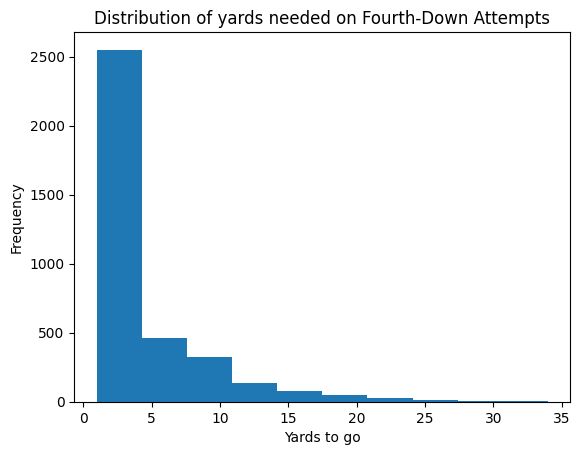

In [24]:
#| fig-cap: "Figure 1: Distribution of yards needed on Fourth-Down Attempts."
# exploratory visualization
plt.hist(X_train["togo"])
plt.xlabel("Yards to go")
plt.ylabel("Frequency")
plt.title("Distribution of yards needed on Fourth-Down Attempts")
plt.show()


The histogram above shows the distribution of yards needed for a first down during fourth-down attempts. As we can see most fourth-down attempts occur when teams need less number of yards. Situations where teams need larger distances happen less often.

### Models

In [25]:
# process data for ML
y_train = (y_train == "Yes").astype(int)
y_test = (y_test == "Yes").astype(int)
model = make_pipeline(FunctionTransformer(operator.methodcaller("to_dict", "records"), validate=False),DictVectorizer(sparse=False),HistGradientBoostingClassifier(max_iter=150,learning_rate=0.05,random_state=37,max_leaf_nodes=16,min_samples_leaf=10))
model.fit(X_train, y_train)

Pipeline(steps=[('functiontransformer',
                 FunctionTransformer(func=operator.methodcaller('to_dict', 'records'))),
                ('dictvectorizer', DictVectorizer(sparse=False)),
                ('histgradientboostingclassifier',
                 HistGradientBoostingClassifier(learning_rate=0.05,
                                                max_iter=150, max_leaf_nodes=16,
                                                min_samples_leaf=10,
                                                random_state=37))])

In [26]:
ytestpred = model.predict(X_test)
probs = model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test,ytestpred)
precision = precision_score(y_test,ytestpred)
recall = recall_score(y_test,ytestpred)
ROCAUC = roc_auc_score(y_test,probs)
logloss = log_loss(y_test,probs)

print(accuracy)
print(precision)
print(recall)
print(ROCAUC)
print(logloss)

0.6254777070063694
0.6666666666666666
0.6904231625835189
0.6631734542369286
0.6464062554295039


The model achieved an accuracy score of 62.5% on the 2024 test data. Since the dataset is mostly balanced, this performance is better than random guessing.

The precision and recall scores show that the model is satisfactory at identifying successful fourth-down conversions.

The ROC AUC score of around 0.66 suggests that the model can differentiate between successful and unsuccessful attempts better than leaving it up to chance.

Performance is still limited because there are a lot of other factors that aren't included like the skill level of the player or the situation of the game.

## Results

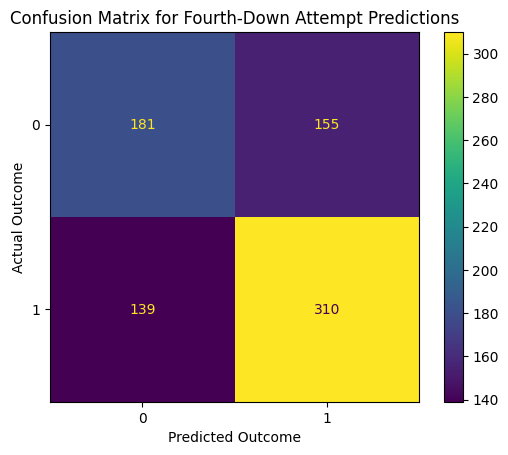

In [27]:
#| fig-cap: "Figure 2: Confusion matrix for fourth-down Attempt Predictions."
#summary figure
ConfusionMatrixDisplay.from_predictions(y_test,ytestpred)
plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")
plt.title("Confusion Matrix for Fourth-Down Attempt Predictions")
plt.show()


The confusion matrix above summarizes the model's predictions on the 2024 test data. The model correctly identified many successful and unsuccessful fourth-down attempts. There were some incorrect predictions, but the model is still better at identifying successful conversions than unsuccessful ones.

In [28]:
# serialize model
joblib.dump(model, "final-project.joblib", compress=9)


['final-project.joblib']

## Discussion

The HistGradientBoosting model performed reasonably well in predicting fourth-down outcomes using various information such as field position, teams involved and yards to go. The model performed better than random guessing and was able to correctly identify a lot of the successful conversion attempts.

The model still has incorrect predictions, most likely due to missing factors in the dataset like player skill and game situation.

To conclude, I would not fully rely on this model but it could be used as a supporting tool, when analyzing fourth-down situations. Additional data and advanced modeling could improve performance substantially.